# Week 5 Day 5 Lab


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import sympy as sp

### Recall: Eigenvalues

An eigenvector is a vector $v$ such that

$$Av=\lambda v.$$

where
- $A$ is a matrix
- $\lambda$ is a scalar (called the eigenvalue)



Suppose$
A=
\begin{bmatrix}
4 & 1\\
1 & 3
\end{bmatrix}$ Note that $A=A^T$. We call these matrices *symmetric*. We can compute the eigenvalues and eigenvectors as follows:

In [4]:
A = np.array([[4,1],[1,3]])
A @ np.linalg.eig(A)[1][:,1]

array([-1.25227364,  2.02622131])

In [5]:
np.linalg.eig(A)[0][1]*np.array([-0.52573111,  0.85065081])

array([-1.25227364,  2.02622132])

### Recall: Quadratic Forms

Consider

$$f(x)=x^TAx$$

This is called a **quadratic form**. If

```python
x = [x₁,x₂]
```
then

```python
A =
[[4,1],
 [1,3]]
```

gives $$f(x)=4x_1^2+2x_1x_2+3x_2^2.$$

Quadratic forms appear throughout optimization. Most importantly, in eigenvalues.

### The Rayleigh Quotient

The quantity

$$
R(A)=\frac{x^TAx}{x^Tx}
$$

is called the **Rayleigh Quotient**.

One of the most important theorems in linear algebra states

$$
\lambda_{\min}(A)\leq R(A)
\leq \lambda_{\max}(A)
$$

And that for symmetric matrices $\min_{x\neq 0}R(A)=\lambda_{\min}$ and $\max_{x\neq 0}R(A)=\lambda_{\max}$ where the $x$'s that acheive these values are the eigenvectors.

Consider drawing these randomly:

In [6]:
values, vectors = np.linalg.eig(A)

largest = np.max(values)

samples = []

for i in range(5000):
    x = np.random.randn(2)
    x = x/np.linalg.norm(x)

    value = x.T @ A @ x

    samples.append(value)

print(max(samples))
print(largest)

4.618033785164424
4.618033988749895


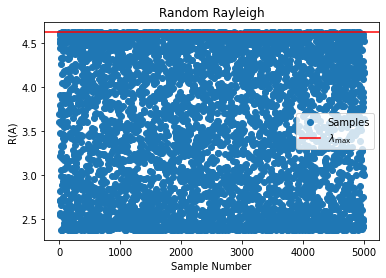

In [7]:
plt.scatter([i for i in range(len(samples))],samples,label='Samples')
plt.axhline(largest, color='red',label=r'$\lambda_{\max}$')
plt.xlabel('Sample Number')
plt.ylabel('R(A)')
plt.title('Random Rayleigh')
plt.legend()

### Problem  1
Write a function that uses `scipy.optimize` to find the largest and smallest eigenvalue of a symmetric two by two matrix.

In [15]:
a=1
b=2
c=3
d=4
def f(x1,x2):
    return(x1*(a*x1 + b*x2)+x2*(c*x1+d*x2))/(x1**2+x2**2)

In [17]:
minimize(f,
         1,1)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.005976354194628
        x: [ 8.372e+02]
      nit: 21
      jac: [-7.138e-06]
 hess_inv: [[ 1.637e+07]]
     nfev: 44
     njev: 22

### Problem 2
Write a function that randomly samples vectors to approximate the largest and smallest eigenvalues. Make this function print the error as well.

### Problem 3
Generalize the function from Problem 1 for arbitrary sized matrices.